<a href="https://colab.research.google.com/github/DianaDoosti-PouyanBahmani/Intelligent-Systems/blob/main/mini%20project%202/MP2_Q6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Generation

In [ ]:
import numpy as np
import pandas as pd

# Define the dynamic system parameters
T = 1000  # Total time steps (t = 2 to t = 999)
u_t = lambda t: np.sin(2 * np.pi * t / 250)  # u(t) = sin(2pi * t / 250)

# Initialize arrays to store the data
y_data = np.zeros(T)  # Initialize y(0) = y(1) = 0
u_values = np.zeros(T)  # To store the values of u(t)

# Generate u(t) and y(t) values for t = 2 to t = 999
for t in range(2, T):
    u_values[t-1] = u_t(t-1)  # u(t-1)
    y_data[t] = y_data[t-1] / (1 + y_data[t-2]) + u_values[t-1]**3  # y(t) based on the dynamic equation

# Create a DataFrame
data = pd.DataFrame({
    'y(t-1)': y_data[1:T-1],  # y(t-1)
    'y(t-2)': y_data[0:T-2],  # y(t-2)
    'u(t-1)': u_values[1:T-1],  # u(t-1)
    'y(t)': y_data[2:T]  # y(t) as the target variable
})

# Split into train and test sets
train_data = data.iloc[:700]
test_data = data.iloc[700:]

# Extract the features and target from the generated data
X_train = train_data[['y(t-1)', 'y(t-2)', 'u(t-1)']].values  # Input features for training
y_train = train_data['y(t)'].values  # Target for training

X_test = test_data[['y(t-1)', 'y(t-2)', 'u(t-1)']].values  # Input features for testing
y_test = test_data['y(t)'].values  # Target for testing


# Show a preview of the generated data
print("Training Data Sample:")
print(train_data.head())
print("\nTraining Data Shape:", train_data.shape)
print("\nTest Data Shape:", test_data.shape)


Training Data Sample:
     y(t-1)    y(t-2)    u(t-1)      y(t)
0  0.000000  0.000000  0.025130  0.000016
1  0.000016  0.000000  0.050244  0.000143
2  0.000143  0.000016  0.075327  0.000570
3  0.000570  0.000143  0.100362  0.001581
4  0.001581  0.000570  0.125333  0.003549

Training Data Shape: (700, 4)

Test Data Shape: (298, 4)


##Data Visualization

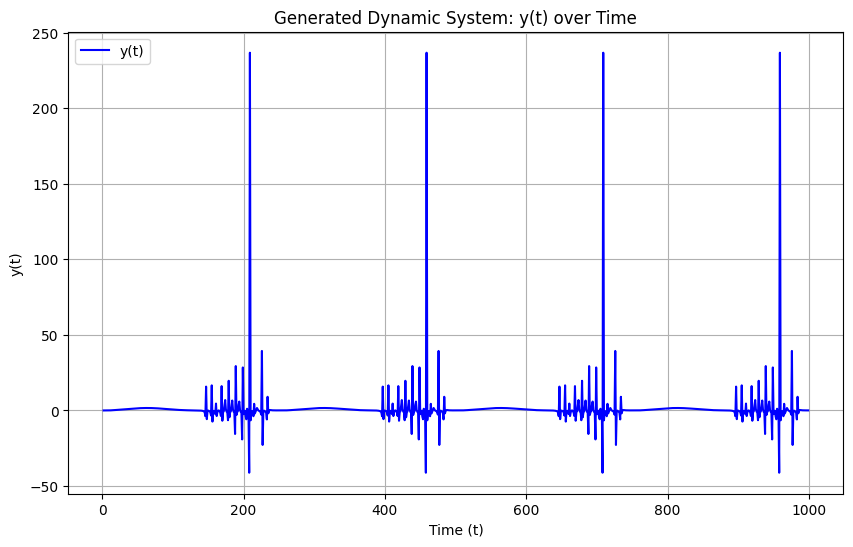

In [ ]:
import matplotlib.pyplot as plt

# Plotting the generated y(t) values
t_values = np.arange(2, T)  # Time steps for t = 2 to t = 999
plt.figure(figsize=(10, 6))
plt.plot(t_values, y_data[2:T], label="y(t)", color='blue')
plt.title("Generated Dynamic System: y(t) over Time")
plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()

# َActivation Function for One Neuron

In [ ]:
import numpy as np

def calculate_single_phi(x, center, sigma):
    # Calculate the squared Euclidean distance between the input x and the center
    distance_squared = np.linalg.norm(x - center)**2

    # Calculate the phi value using the Gaussian function
    phi = np.exp(-distance_squared / (2 * sigma**2))
    return phi

# execution:
x = np.array([1, 1])  # Example input data point
center = np.array([1, 1])  # The center is the same as the input
sigma = 1.0  # Example spread (sigma)

# Calculate phi for the input data point and the same center
phi_value = calculate_single_phi(x, center, sigma)
print(f"The phi value for the input x and center {center} with sigma {sigma} is: {phi_value}")


The phi value for the input x and center [1 1] with sigma 1.0 is: 1.0


#Static RBFNN Model

## Class Defenition

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class RBFNN:
    def __init__(self, centers=None, spread=None):
        self.spread = spread  # spread (sigma) of the RBFs, can be None
        self.centers = centers  # Pre-defined centers
        self.weights = None  # will store the weights for the RBFNN
        self.phi_train = None  # will store the phi matrix for training set

    def calculate_sigma(self):
        # If spread (sigma) is not provided, calculate it from the centers
        if self.spread is None:
            # Calculate pairwise distances between all centers
            distances = np.linalg.norm(self.centers[:, np.newaxis] - self.centers, axis=2)
            # Compute sigma as the average of all pairwise distances
            self.spread = np.mean(distances)
        return self.spread

    def calculate_phi(self, X, sigma=None):
        # If sigma is provided, use it; otherwise, calculate it
        if sigma is None:
            sigma = self.calculate_sigma()

        K = self.centers.shape[0]
        phi = np.zeros((X.shape[0], K))
        for i in range(X.shape[0]):
            for k in range(K):
                phi[i, k] = np.exp(-np.linalg.norm(X[i] - self.centers[k])**2 / (sigma**2))
        return phi

    def train(self, X_train, y_train):
        # Step 1: Calculate the spread (sigma) if it's not provided
        sigma = self.calculate_sigma()

        # Step 2: Calculate the phi matrix for the training set and store it
        self.phi_train = self.calculate_phi(X_train, sigma)

        # Step 3: Calculate the weights using Linear Least Squares (WLS)
        self.weights = np.linalg.pinv(self.phi_train.T @ self.phi_train) @ self.phi_train.T @ y_train

    def predict(self, X):
        # Use the pre-calculated sigma (from training)
        sigma = self.spread  # Use the already calculated sigma
        K = self.centers.shape[0]  # Number of centers (K)

        # Step 1: Calculate the phi matrix for the test set
        phi_test = self.calculate_phi(X, sigma)  # Only calculate phi_test here for prediction

        # Step 3: Predict using the learned weights
        return phi_test @ self.weights

    def rmse(self, y_true, y_pred):
        # Calculate Root Mean Squared Error (RMSE)
        return np.sqrt(np.mean((y_true - y_pred) ** 2))

    def plot_approximated_function(self, X_test, y_test):
        # Predict the test set outputs using the model
        y_pred = self.predict(X_test)

        # Plot the true values vs the predicted values
        plt.figure(figsize=(10, 6))
        plt.plot(np.arange(2, len(y_test) + 2), y_test, label="True Function y(t)", color='blue', linestyle='--')
        plt.plot(np.arange(2, len(y_test) + 2), y_pred, label="Approximated Function (RBFNN)", color='red')
        plt.title(f"True Function vs Approximated Function for k={self.centers.shape[0]} and spread= {self.calculate_sigma()}")
        plt.xlabel("Time (t)")
        plt.ylabel("y(t)")
        plt.legend()
        plt.grid(True)
        plt.show()


##Basic Implementaion of the Static RBFNN with K=45

###Selecting Reproducatable Random Centers

In [ ]:
import numpy as np

def pick_random_centers(X_train, K, seed=42):
    np.random.seed(seed)  # Fix the random seed for reproducibility
    indices = np.random.choice(X_train.shape[0], K, replace=False)
    centers = X_train[indices]
    return centers

In [ ]:
# Select centers using the external function
centers_45 = pick_random_centers(X_train, K=45, seed=42)

### Running the Model

Train RMSE: 13.430091643840203
Test RMSE: 20.181700632397305
train set approximation


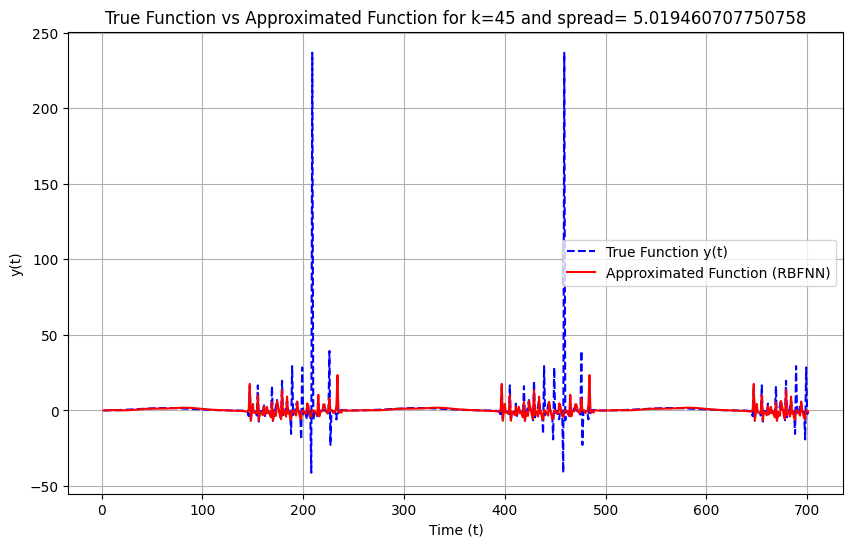

test set approximation


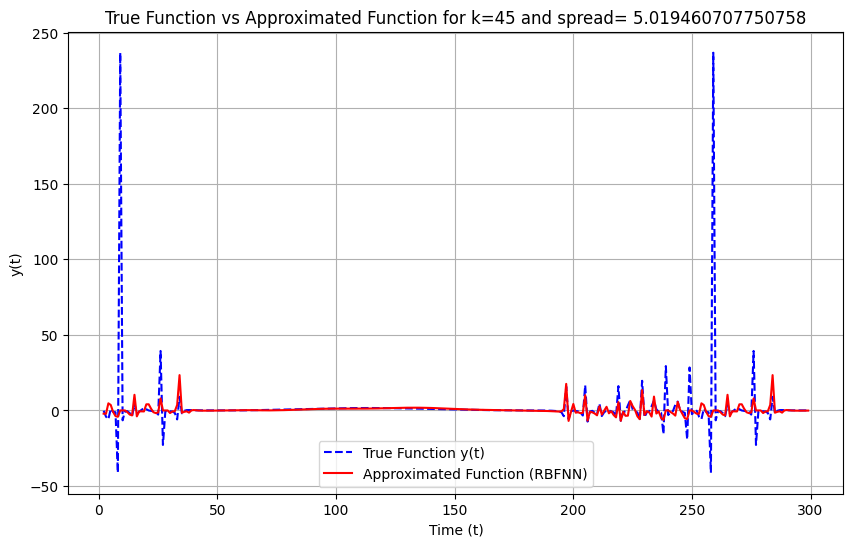

In [ ]:
# Initialize and train the original RBFNN model
rbfnn = RBFNN(centers=centers_45, spread=None)
rbfnn.train(X_train, y_train)

# Predict and evaluate the model
y_pred = rbfnn.predict(X_train)
train_rmse = rbfnn.rmse(y_train, y_pred)
print(f"Train RMSE: {train_rmse}")

y_pred = rbfnn.predict(X_test)
test_rmse = rbfnn.rmse(y_test, y_pred)
print(f"Test RMSE: {test_rmse}")

# Plot the approximated function vs. the true function in the train set
print("train set approximation")
rbfnn.plot_approximated_function(X_train, y_train)

print("test set approximation")
# Plot the approximated function vs the true function
rbfnn.plot_approximated_function(X_test, y_test)

#Finding the Optimal K and Sigma for Static RBFNN

##Helper Functions

In [ ]:
# RBFNN class is already defined and uses external centers

def run_experiment_for_K(X_train, y_train, X_test, y_test, K_values, centers_dict, sigma_value=1):
    test_rmses = []
    train_rmses = []

    for K in K_values:
        centers = centers_dict[K]
        rbfnn = RBFNN(centers=centers, spread=sigma_value)
        rbfnn.train(X_train, y_train)

        train_pred = rbfnn.predict(X_train)
        test_pred = rbfnn.predict(X_test)

        train_rmse = rbfnn.rmse(y_train, train_pred)
        test_rmse = rbfnn.rmse(y_test, test_pred)

        train_rmses.append(train_rmse)
        test_rmses.append(test_rmse)

    plt.figure(figsize=(8, 6))
    plt.plot(K_values, train_rmses, label="Train RMSE", marker='o')
    plt.plot(K_values, test_rmses, label="Test RMSE", marker='o')
    plt.title("Train and Test RMSE vs. K")
    plt.xlabel("Number of Centers (K)")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()

    best_idx = np.argmin(test_rmses)
    best_K = K_values[best_idx]
    print(f"Best K: {best_K} with Test RMSE: {test_rmses[best_idx]} and Train RMSE: {train_rmses[best_idx]}")

    return best_K


def run_experiment_for_sigma(X_train, y_train, X_test, y_test, best_K, centers_bestK, sigma_values):
    test_rmses = []
    train_rmses = []

    for sigma in sigma_values:
        rbfnn = RBFNN(centers=centers_bestK, spread=sigma)
        rbfnn.train(X_train, y_train)

        train_pred = rbfnn.predict(X_train)
        test_pred = rbfnn.predict(X_test)

        train_rmse = rbfnn.rmse(y_train, train_pred)
        test_rmse = rbfnn.rmse(y_test, test_pred)

        train_rmses.append(train_rmse)
        test_rmses.append(test_rmse)

    plt.figure(figsize=(8, 6))
    plt.plot(sigma_values, train_rmses, label="Train RMSE", marker='o')
    plt.plot(sigma_values, test_rmses, label="Test RMSE", marker='o')
    plt.title("Train and Test RMSE vs. Sigma")
    plt.xlabel("Sigma")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()

    best_idx = np.argmin(test_rmses)
    best_sigma = sigma_values[best_idx]
    print(f"Best sigma: {best_sigma} with Test RMSE: {test_rmses[best_idx]} and Train RMSE: {train_rmses[best_idx]}")

    return best_sigma


def final_model_evaluation(X_train, y_train, X_test, y_test, best_K, centers_bestK, best_sigma):
    rbfnn = RBFNN(centers=centers_bestK, spread=best_sigma)
    rbfnn.train(X_train, y_train)

    train_pred = rbfnn.predict(X_train)
    test_pred = rbfnn.predict(X_test)

    train_rmse = rbfnn.rmse(y_train, train_pred)
    test_rmse = rbfnn.rmse(y_test, test_pred)

    print(f"Train RMSE: {train_rmse}")
    print(f"Test RMSE: {test_rmse}")

    rbfnn.plot_approximated_function(X_test, y_test)


##Initialization of Centers + Implementation

In [ ]:
K_values = [10, 20, 50, 100, 200]
sigma_values = [0.5, 1, 5, 7, 10]

centers_dict = {K: pick_random_centers(X_train, K, seed=42) for idx, K in enumerate(K_values)}

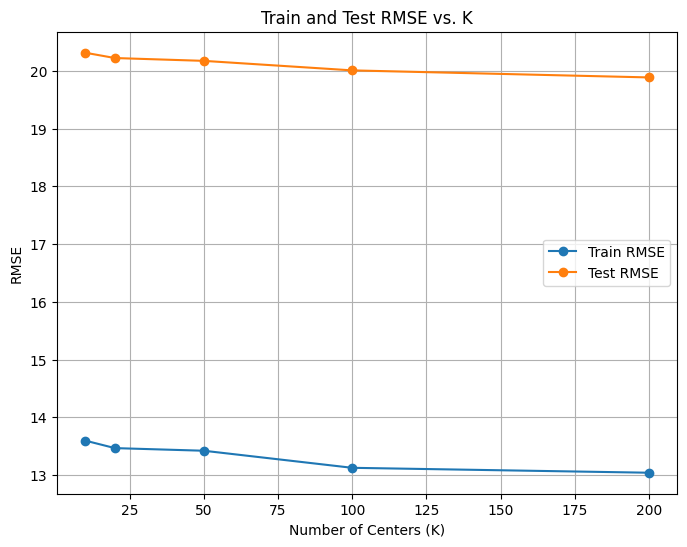

Best K: 200 with Test RMSE: 19.886265813792686 and Train RMSE: 13.039587399415135


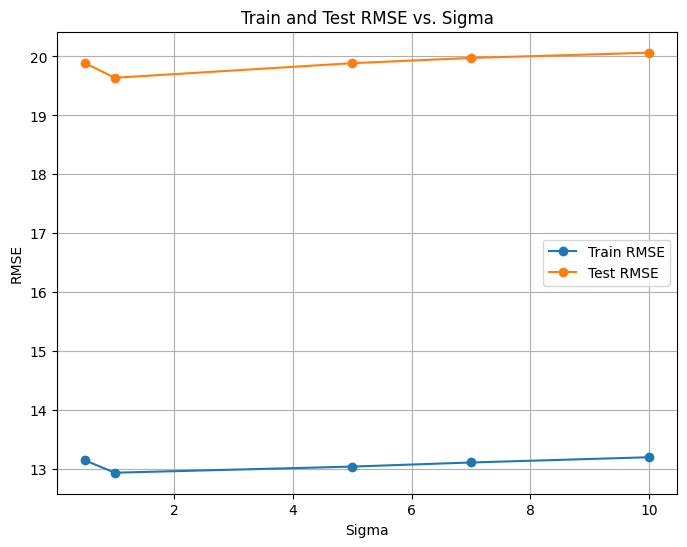

Best sigma: 1 with Test RMSE: 19.638973572848613 and Train RMSE: 12.935512889311498
Train RMSE: 12.935512889311498
Test RMSE: 19.638973572848613


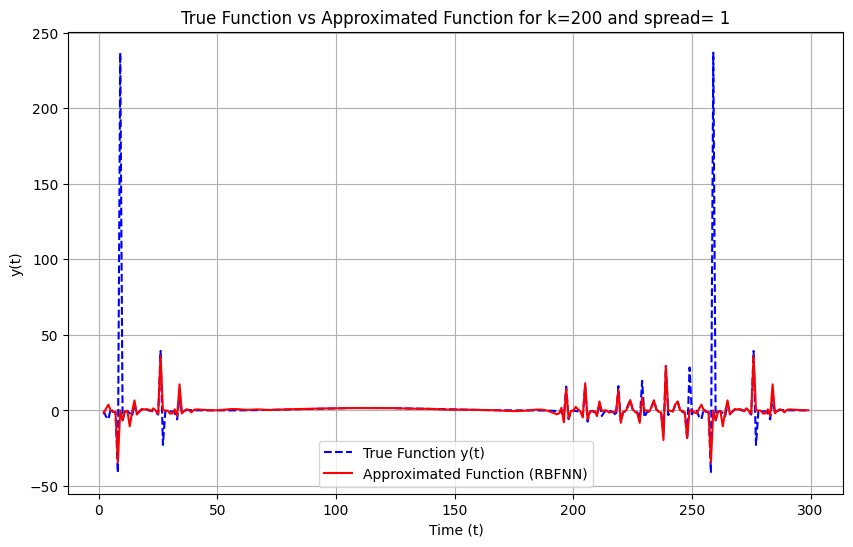

In [ ]:
best_K = run_experiment_for_K(X_train, y_train, X_test, y_test, K_values, centers_dict, sigma_value=5)

centers_bestK = centers_dict[best_K]

best_sigma = run_experiment_for_sigma(X_train, y_train, X_test, y_test, best_K, centers_bestK, sigma_values)

final_model_evaluation(X_train, y_train, X_test, y_test, best_K, centers_bestK, best_sigma)

#Class Defenition for RBFNN with L2_Regularization

In [ ]:
class RBFNN_L2:
    def __init__(self, centers=None, spread=None, lambda_reg=1.0):
        self.spread = spread  # spread (sigma) of the RBFs, can be None
        self.lambda_reg = lambda_reg  # regularization parameter (lambda)
        self.centers = centers  # Pre-defined centers
        self.weights = None  # will store the weights for the RBFNN
        self.phi_train = None  # will store the phi matrix for training set

    def calculate_sigma(self):
        # If spread (sigma) is not provided, calculate it from the centers
        if self.spread is None:
            # Calculate pairwise distances between all centers
            distances = np.linalg.norm(self.centers[:, np.newaxis] - self.centers, axis=2)
            # Compute sigma as the average of all pairwise distances
            self.spread = np.mean(distances)
        return self.spread

    def calculate_phi(self, X, sigma=None):
        # If sigma is provided, use it; otherwise, calculate it
        if sigma is None:
            sigma = self.calculate_sigma()

        K = self.centers.shape[0]
        phi = np.zeros((X.shape[0], K))
        for i in range(X.shape[0]):
            for k in range(K):
                phi[i, k] = np.exp(-np.linalg.norm(X[i] - self.centers[k])**2 / (sigma**2))
        return phi

    def train(self, X_train, y_train):
        # Step 1: Calculate the spread (sigma) if it's not provided
        sigma = self.calculate_sigma()

        # Step 2: Calculate the phi matrix for the training set and store it
        self.phi_train = self.calculate_phi(X_train, sigma)

        # Step 3: Calculate the weights using L2 regularized Linear Least Squares (LLS)
        phi_transpose_phi = self.phi_train.T @ self.phi_train
        regularization_term = self.lambda_reg * np.eye(self.phi_train.shape[1])
        self.weights = np.linalg.pinv(phi_transpose_phi + regularization_term) @ self.phi_train.T @ y_train

    def predict(self, X):
        # Use the pre-calculated sigma (from training)
        sigma = self.spread  # Use the already calculated sigma
        K = self.centers.shape[0]  # Number of centers (K)

        # Step 1: Calculate the phi matrix for the test set
        phi_test = self.calculate_phi(X, sigma)  # Only calculate phi_test here for prediction

        # Step 3: Predict using the learned weights
        return phi_test @ self.weights

    def rmse(self, y_true, y_pred):
        # Calculate Root Mean Squared Error (RMSE)
        return np.sqrt(np.mean((y_true - y_pred) ** 2))

    def plot_approximated_function(self, X_test, y_test):
        # Predict the test set outputs using the model
        y_pred = self.predict(X_test)

        # Plot the true values vs the predicted values
        plt.figure(figsize=(10, 6))
        plt.plot(np.arange(2, len(y_test) + 2), y_test, label="True Function y(t)", color='blue', linestyle='--')
        plt.plot(np.arange(2, len(y_test) + 2), y_pred, label="Approximated Function (RBFNN)", color='red')
        plt.title(f"True Function vs Approximated Function for k={self.centers.shape[0]} and spread= {self.calculate_sigma()}")
        plt.xlabel("Time (t)")
        plt.ylabel("y(t)")
        plt.legend()
        plt.grid(True)
        plt.show()

##Implementation of RBFNN_L2 for Different Lambda

Train RMSE: 13.5554051828741
Test RMSE: 20.288860209600028
train set approximation


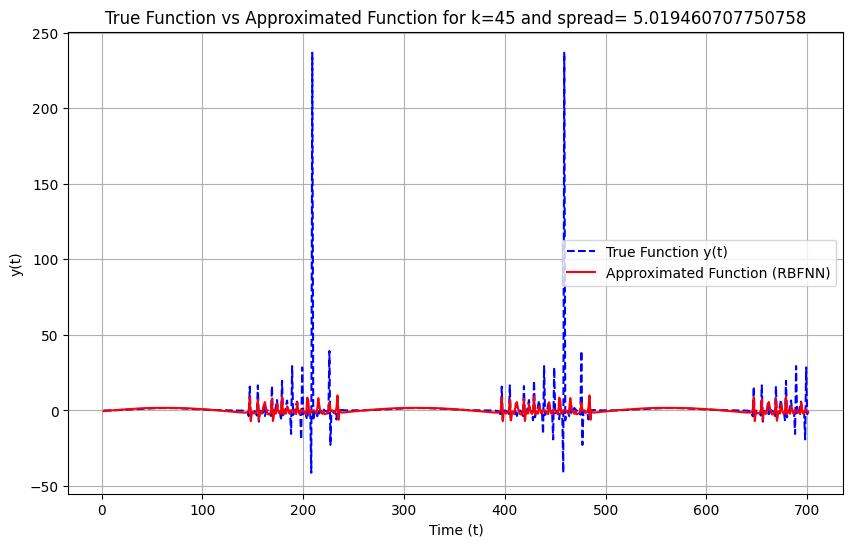

test set approximation


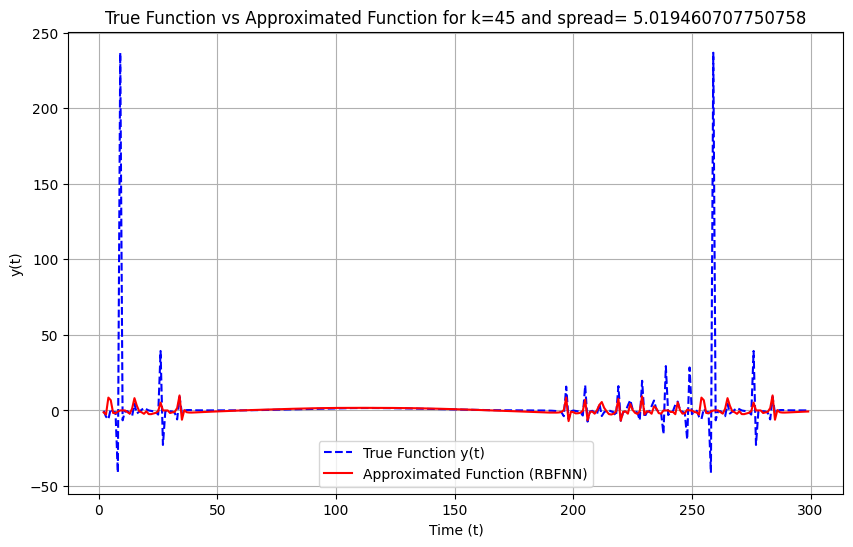

In [ ]:
# Initialize and train the L2 regularized RBFNN model (using the same centers from the static RBFNN basic implementation)
rbfnn_l2 = RBFNN_L2(centers=centers_45, spread=None, lambda_reg=0.01)
rbfnn_l2.train(X_train, y_train)

# Predict and evaluate the model
y_pred_l2 = rbfnn_l2.predict(X_train)
train_rmse_l2 = rbfnn_l2.rmse(y_train, y_pred_l2)
print(f"Train RMSE: {train_rmse_l2}")

y_pred_l2 = rbfnn_l2.predict(X_test)
test_rmse_l2 = rbfnn_l2.rmse(y_test, y_pred_l2)
print(f"Test RMSE: {test_rmse_l2}")

# Plot the approximated function vs. the true function in the train set
print("train set approximation")
rbfnn_l2.plot_approximated_function(X_train, y_train)

print("test set approximation")
# Plot the approximated function vs the true function
rbfnn_l2.plot_approximated_function(X_test, y_test)

# K-Means Clustering Method

##K-means function defenition

In [ ]:
def kmeans_centers(X, K, max_iters=100, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    N, D = X.shape

    # 1) initialize centers by choosing K random points
    indices = np.random.choice(N, K, replace=False)
    centers = X[indices].copy()

    for _ in range(max_iters):
        # 2) assign each point to nearest center
        # distances: (N, K)
        distances = np.linalg.norm(X[:, np.newaxis, :] - centers[np.newaxis, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        # 3) recompute centers as mean of assigned points
        new_centers = np.zeros_like(centers)
        for k in range(K):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                new_centers[k] = cluster_points.mean(axis=0)
            else:
                # if a cluster gets no points, reinitialize it randomly
                new_centers[k] = X[np.random.randint(0, N)]

        # 4) check convergence
        if np.allclose(new_centers, centers):
            break

        centers = new_centers

    return centers

In [ ]:
K = 45
centers_k = kmeans_centers(X_train, K, random_state=42)

## Implementing Static RBFNN with new K-Means Centers

Train RMSE: 13.257606019162708
Test RMSE: 20.087293387807076
train set approximation


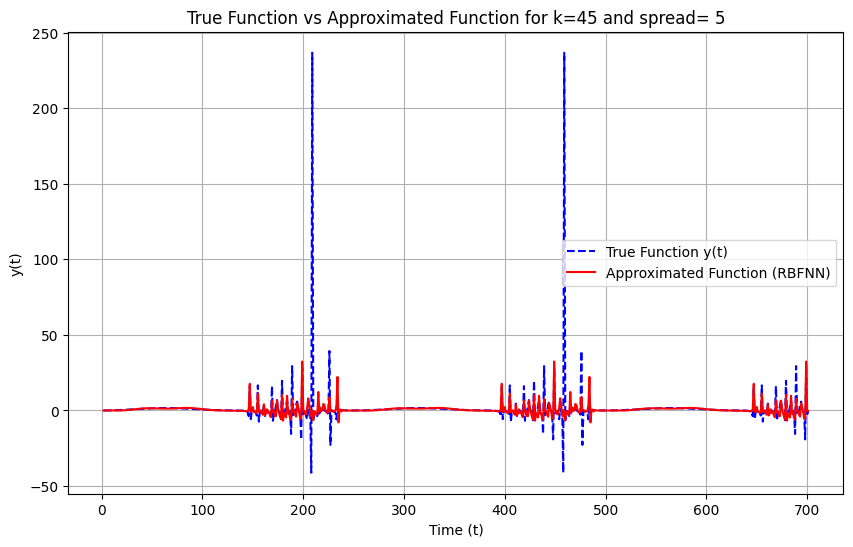

test set approximation


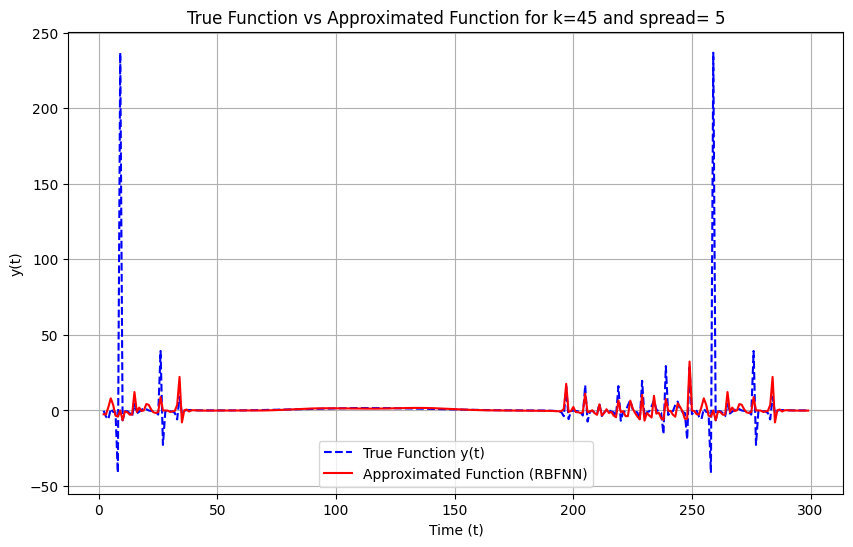

In [ ]:
# Initialize and train the original RBFNN model
rbfnn = RBFNN(centers=centers_k, spread=5)
rbfnn.train(X_train, y_train)

# Predict and evaluate the model
y_pred = rbfnn.predict(X_train)
train_rmse = rbfnn.rmse(y_train, y_pred)
print(f"Train RMSE: {train_rmse}")

y_pred = rbfnn.predict(X_test)
test_rmse = rbfnn.rmse(y_test, y_pred)
print(f"Test RMSE: {test_rmse}")

# Plot the approximated function vs. the true function in the train set
print("train set approximation")
rbfnn.plot_approximated_function(X_train, y_train)

print("test set approximation")
# Plot the approximated function vs the true function
rbfnn.plot_approximated_function(X_test, y_test)

## New RBFNN Class for picking Spreads

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class RBFNN:
    def __init__(self, centers=None, p=3):
        self.centers = centers
        self.p = p
        self.sigmas = None       # per-center spreads (length K)
        self.weights = None
        self.phi_train = None

    def calculate_sigmas(self):
        """
        Compute a different sigma for each center using its p nearest neighbors.
        sigma_k = mean of distances to the p closest other centers.
        """
        if self.sigmas is not None:
            return self.sigmas

        if self.centers is None:
            raise ValueError("Centers must be set before computing sigmas.")

        K = self.centers.shape[0]
        if K < 2:
            # Degenerate case: only one center
            self.sigmas = np.ones(K)
            return self.sigmas

        # Pairwise distances between centers: shape (K, K)
        dists = np.linalg.norm(
            self.centers[:, np.newaxis, :] - self.centers[np.newaxis, :, :],
            axis=2
        )

        # Ignore distance to self by setting diagonal to +inf
        np.fill_diagonal(dists, np.inf)

        # How many neighbors can we actually use? (at most K-1)
        p_eff = min(self.p, K - 1)

        # Sort distances row-wise and take p nearest for each center
        sorted_dists = np.sort(dists, axis=1)
        nearest = sorted_dists[:, :p_eff]  # shape (K, p_eff)

        # Sigma for each center = mean of its p nearest distances
        sigmas = nearest.mean(axis=1)

        # Avoid sigma = 0 (just in case)
        sigmas[sigmas == 0] = 1e-6

        self.sigmas = sigmas
        return self.sigmas

    def calculate_phi(self, X):
        if self.centers is None:
            raise ValueError("Centers must be set before calling calculate_phi.")

        sigmas = self.calculate_sigmas()      # shape (K,)
        K = self.centers.shape[0]
        N = X.shape[0]

        phi = np.zeros((N, K))

        for k in range(K):
            sigma_k = sigmas[k]
            diff = X - self.centers[k]       # shape (N, d)
            dist_sq = np.sum(diff**2, axis=1)
            phi[:, k] = np.exp(-dist_sq / (2 * sigma_k**2))

        return phi

    def train(self, X_train, y_train):
        # Ensure sigmas are computed (implicitly uses centers and p)
        self.calculate_sigmas()

        self.phi_train = self.calculate_phi(X_train)
        # Least squares: w = (Phi^T Phi)^(-1) Phi^T y
        self.weights = np.linalg.pinv(self.phi_train.T @ self.phi_train) @ self.phi_train.T @ y_train

    def predict(self, X):
        phi_test = self.calculate_phi(X)
        return phi_test @ self.weights

    def rmse(self, y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred) ** 2))

    def plot_approximated_function(self, X_test, y_test):
        y_pred = self.predict(X_test)

        plt.figure(figsize=(10, 6))
        plt.plot(np.arange(2, len(y_test) + 2), y_test,
                 label="True Function y(t)", linestyle='--')
        plt.plot(np.arange(2, len(y_test) + 2), y_pred,
                 label="Approximated Function (RBFNN)")
        plt.title(
            f"True vs Approximated, K={self.centers.shape[0]}, p={self.p}"
        )
        plt.xlabel("Time (t)")
        plt.ylabel("y(t)")
        plt.legend()
        plt.grid(True)
        plt.show()


### Implementing new K-means Model

Train RMSE: 10.383172417908783
Test  RMSE: 14.911133305564595


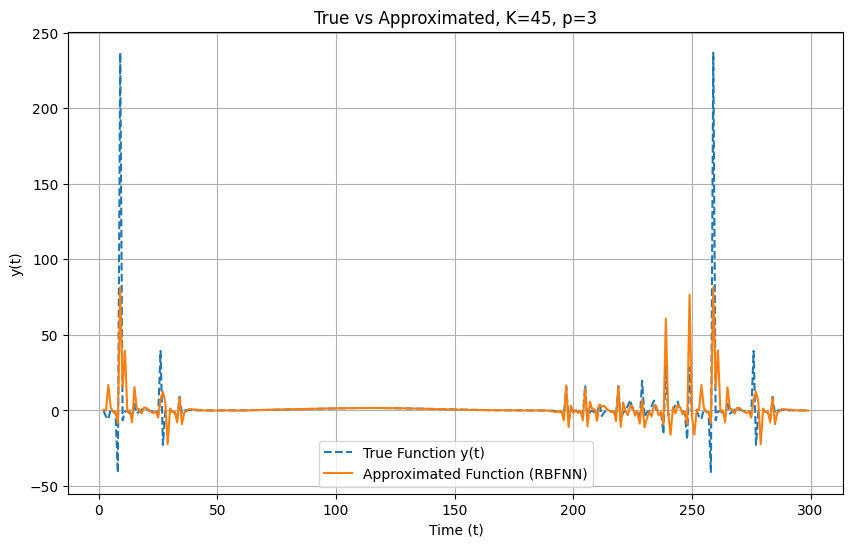

In [ ]:
# build and train model
rbfnn = RBFNN(centers=centers_k, p=3)
rbfnn.train(X_train, y_train)

# evaluate
train_pred = rbfnn.predict(X_train)
test_pred  = rbfnn.predict(X_test)

print("Train RMSE:", rbfnn.rmse(y_train, train_pred))
print("Test  RMSE:", rbfnn.rmse(y_test,  test_pred))

# plot
rbfnn.plot_approximated_function(X_test, y_test)

#RBFNN Inspired by M-RAN

## Basic Evaluation Function for Sequential Learning

In [ ]:
import numpy as np

def should_add_neuron(x_n, y_n, y_pred, dist_to_nearest_center, eps, e_min):
    novelty = dist_to_nearest_center > eps
    error_big = abs(y_n - y_pred) > e_min
    return novelty and error_big


In [ ]:
eps = 1.0
e_min = 0.5

x_n = np.array([0.2, 0.7])
y_n = 1.0
y_pred = 0.3
dist_to_nearest_center = 1.4

print(should_add_neuron(x_n, y_n, y_pred, dist_to_nearest_center, eps, e_min))

True
